# Low-correlation pair with a "top 50% of regimes" filter

Applies a market-regime entry filter to `combination.ipynb`'s
**least-correlated pair** (MES SuperTrend + MNQ Bollinger MR, correlation
0.291 -- the lowest of all 15 sleeve pairs, see `combination.ipynb`'s own
correlation-matrix section), using a **different, stricter filter rule**
than `combined_with_regime_filter.ipynb`'s `profit_factor > 1` gate.

**The rule this time**: rank each sleeve's four regimes by `profit_factor`
(entry performance), keep only the **top 50% (top 2 of 4)**, skip entries in
the bottom half regardless of how good or bad they look in absolute terms.
This is a stricter, always-exactly-half filter, unlike `profit_factor > 1`
which happened to keep all four regimes for both of these specific sleeves
last time (neither MES SuperTrend nor MNQ Bollinger MR had any sub-1.0
regime) -- so this notebook tests a real, different cut on exactly the two
sleeves the earlier filter left untouched.

Same `RegimeGatedStrategy` wrapper, same regime classification (ADX x
rolling-vol-percentile on daily bars), same 30-minute execution and
`weight=1.0` each (one sleeve per symbol, matching `combination.ipynb`'s own
"BMR PAIR"/"LOW-CORR PAIR" sections) -- only the gating *rule* differs.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import (
    BollingerMeanReversionStrategy,
    RegimeGatedStrategy,
    StrategyDirection,
    SuperTrendFlipStrategy,
)
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


MES_SYMBOL = "MES/USD"
MNQ_SYMBOL = "MNQ/USD"
INTERVAL = 30
UNIT_OF_TIME = "minute"
DEPOSIT_USD = 50_000

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
mnq_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))

ohlc_mes = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
ohlc_mnq = load_1m_parquet_resampled(mnq_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"MES 30m bars: {len(ohlc_mes)}  span: {ohlc_mes.index[0]} -> {ohlc_mes.index[-1]}")
print(f"MNQ 30m bars: {len(ohlc_mnq)}  span: {ohlc_mnq.index[0]} -> {ohlc_mnq.index[-1]}")

ohlc_mes_daily = load_1m_parquet_resampled(mes_path, interval=1, unit_of_time="day")
ohlc_mnq_daily = load_1m_parquet_resampled(mnq_path, interval=1, unit_of_time="day")


MES 30m bars: 84421  span: 2019-05-05 22:29:59.999000 -> 2026-07-12 23:29:59.999000
MNQ 30m bars: 84428  span: 2019-05-05 22:29:59.999000 -> 2026-07-13 07:29:59.999000


## Regime classification (identical method to `market_regime_detection.ipynb`)


In [3]:
ADX_LENGTH = 14
VOL_LOOKBACK = 20
VOL_PERCENTILE_WINDOW = 252
REGIME_ORDER = ["Trending / Low-Vol", "Trending / High-Vol", "Choppy / Low-Vol", "Choppy / High-Vol"]


def compute_regime(ohlc: pd.DataFrame) -> pd.Series:
    df = ohlc.copy()
    df["adx"] = Indicators.adx(df, length=ADX_LENGTH)
    is_trending = df["adx"] >= 25

    log_returns = np.log(df["close"] / df["close"].shift(1))
    realized_vol = log_returns.rolling(VOL_LOOKBACK).std() * np.sqrt(252)
    vol_percentile = realized_vol.rolling(VOL_PERCENTILE_WINDOW, min_periods=60).rank(pct=True)
    is_high_vol = vol_percentile >= 0.5

    conditions = [
        is_trending & ~is_high_vol,
        is_trending & is_high_vol,
        ~is_trending & ~is_high_vol,
        ~is_trending & is_high_vol,
    ]
    regime = pd.Series(np.select(conditions, REGIME_ORDER, default="Unclassified"), index=df.index)
    regime[regime == "Unclassified"] = np.nan
    regime.name = "regime"
    return regime


regime_mes = compute_regime(ohlc_mes_daily)
regime_mnq = compute_regime(ohlc_mnq_daily)


## Unfiltered solo runs for the two sleeves, tagged with entry regime

Same params as `combination.ipynb`'s "LOW-CORR PAIR": MES SuperTrend
(length=50, multiplier=3.0) and MNQ Bollinger MR (bb_length=10,
bb_std_dev=2.5, sl_percent=0.02, tp_percent=0.01), both `direction=long`.


In [4]:
def run_solo_backtest(symbol: str, ohlc: pd.DataFrame, make_strategy, key: str):
    market = Market()
    market.add_market(symbol=symbol, df=ohlc)
    make_strategy["add_indicators"](market, symbol, ohlc)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=make_strategy["strategy"](market, key)),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[symbol], periods_per_year=252)
    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, portfolio.weighted_strategies[0].strategy


UNFILTERED_DEFS = {
    "MES SuperTrend": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "strategy": lambda market, key: SuperTrendFlipStrategy(
            key=key, market=market, symbol=MES_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
            direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_line", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_direction", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[1]),
        ],
    },
    "MNQ Bollinger MR": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "strategy": lambda market, key: BollingerMeanReversionStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_lower", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_upper", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[2]),
        ],
    },
}

sleeve_trade_dfs = {}
for name, cfg in UNFILTERED_DEFS.items():
    bt, strategy = run_solo_backtest(cfg["symbol"], cfg["ohlc"], cfg, key=f"{name}_unfiltered_tag")
    rows = []
    for trade in strategy.trade_history:
        regime = cfg["regime"].asof(trade.time_open) if trade.time_open is not None else None
        rows.append({"time_open": trade.time_open, "pnl": trade.pnl, "regime": regime})
    sleeve_trade_dfs[name] = pd.DataFrame(rows)
    print(f"{name}: {len(sleeve_trade_dfs[name])} trades tagged")


MES SuperTrend: 1109 trades tagged


MNQ Bollinger MR: 1099 trades tagged


## Rank regimes by profit_factor, keep the top 50% (top 2 of 4)

Unlike `combined_with_regime_filter.ipynb`'s `profit_factor > 1` gate (which
happened to keep all four regimes for both of these sleeves), this always
excludes exactly half the regimes -- a stricter cut regardless of how good
the excluded ones look in absolute terms.


In [5]:
def regime_profit_factors(trades_df: pd.DataFrame) -> pd.Series:
    out = {}
    for regime in REGIME_ORDER:
        pnls = trades_df.loc[trades_df["regime"] == regime, "pnl"].to_numpy()
        gross_win = pnls[pnls > 0].sum()
        gross_loss = -pnls[pnls < 0].sum()
        out[regime] = (gross_win / gross_loss) if gross_loss > 0 else float("nan")
    return pd.Series(out)


ALLOWED_REGIMES = {}
for name, trades_df in sleeve_trade_dfs.items():
    pf = regime_profit_factors(trades_df).sort_values(ascending=False)
    top_half = set(pf.index[:2])
    ALLOWED_REGIMES[name] = top_half
    print(f"=== {name} ===")
    print(pf.to_string())
    print(f"  top 50% (allowed): {top_half}")
    print(f"  bottom 50% (excluded): {set(REGIME_ORDER) - top_half}")
    print()


=== MES SuperTrend ===
Choppy / Low-Vol       1.485594
Trending / Low-Vol     1.281324
Trending / High-Vol    1.136669
Choppy / High-Vol      1.065598
  top 50% (allowed): {'Choppy / Low-Vol', 'Trending / Low-Vol'}
  bottom 50% (excluded): {'Trending / High-Vol', 'Choppy / High-Vol'}

=== MNQ Bollinger MR ===
Trending / High-Vol    1.546053
Choppy / Low-Vol       1.487342
Trending / Low-Vol     1.465517
Choppy / High-Vol      1.414894
  top 50% (allowed): {'Trending / High-Vol', 'Choppy / Low-Vol'}
  bottom 50% (excluded): {'Choppy / High-Vol', 'Trending / Low-Vol'}



## Sleeve definitions with the regime gate applied


In [6]:
SLEEVE_DEFS = {
    "MES SuperTrend": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "make_strategy": lambda market, key: RegimeGatedStrategy(
            key=key, market=market, symbol=MES_SYMBOL, regime_key="regime",
            allowed_regimes=ALLOWED_REGIMES["MES SuperTrend"],
            inner=SuperTrendFlipStrategy(
                key=f"{key}_inner", market=market, symbol=MES_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
                direction=StrategyDirection.long,
            ),
        ),
        "add_indicators": UNFILTERED_DEFS["MES SuperTrend"]["add_indicators"],
    },
    "MNQ Bollinger MR": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "make_strategy": lambda market, key: RegimeGatedStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, regime_key="regime",
            allowed_regimes=ALLOWED_REGIMES["MNQ Bollinger MR"],
            inner=BollingerMeanReversionStrategy(
                key=f"{key}_inner", market=market, symbol=MNQ_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
                sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long,
            ),
        ),
        "add_indicators": UNFILTERED_DEFS["MNQ Bollinger MR"]["add_indicators"],
    },
}


def build_backtest(sleeve_names: list[str], weight: float, key_suffix: str, use_filter: bool):
    defs = SLEEVE_DEFS if use_filter else UNFILTERED_DEFS
    strategy_key = "make_strategy" if use_filter else "strategy"

    market = Market()
    added_symbols = set()
    for name in sleeve_names:
        cfg = defs[name]
        if cfg["symbol"] not in added_symbols:
            market.add_market(symbol=cfg["symbol"], df=cfg["ohlc"])
            added_symbols.add(cfg["symbol"])
    for name in sleeve_names:
        cfg = defs[name]
        cfg["add_indicators"](market, cfg["symbol"], cfg["ohlc"])
        if use_filter:
            market.add_indicator(symbol=cfg["symbol"], interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="regime", df=cfg["regime"])
    market.compile()

    weighted_strategies = [
        WeightedStrategy(weight=weight, strategy=defs[name][strategy_key](market, f"{name}_{key_suffix}"))
        for name in sleeve_names
    ]
    portfolio = Portfolio(weighted_strategies=weighted_strategies, output_scale=1)
    benchmark_symbols = sorted({defs[name]["symbol"] for name in sleeve_names})
    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
        leverage_aware_sizing=False,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=benchmark_symbols, periods_per_year=252)
    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


## Unfiltered vs. filtered: solo sleeves and the pair


In [7]:
def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "win_rate_percent": summary["win_rate_percent"], "dollar_profit_factor": summary["dollar_profit_factor"],
        "dollar_expectancy": summary["dollar_expectancy"], "total_fees_usd": total_fees,
        "account_failed": drawdown_mw.account_failed,
    })
    return row


results_rows = []
backtests = {}
_t0 = time.time()

for name in SLEEVE_DEFS:
    bt_u, mw_u = build_backtest([name], weight=1.0, key_suffix="solo_unfiltered", use_filter=False)
    backtests[f"{name} (unfiltered)"] = (bt_u, mw_u)
    results_rows.append({"run": f"{name} (unfiltered)", **_summarize(bt_u, mw_u)})

    bt_f, mw_f = build_backtest([name], weight=1.0, key_suffix="solo_filtered", use_filter=True)
    backtests[f"{name} (regime-filtered)"] = (bt_f, mw_f)
    results_rows.append({"run": f"{name} (regime-filtered)", **_summarize(bt_f, mw_f)})
    print(f"{name} done, {time.time() - _t0:.0f}s elapsed", flush=True)

pair_unfiltered_bt, pair_unfiltered_mw = build_backtest(list(SLEEVE_DEFS.keys()), weight=1.0, key_suffix="pair_unfiltered", use_filter=False)
backtests["PAIR unfiltered"] = (pair_unfiltered_bt, pair_unfiltered_mw)
results_rows.append({"run": "PAIR unfiltered", **_summarize(pair_unfiltered_bt, pair_unfiltered_mw)})

pair_filtered_bt, pair_filtered_mw = build_backtest(list(SLEEVE_DEFS.keys()), weight=1.0, key_suffix="pair_filtered", use_filter=True)
backtests["PAIR regime-filtered (top 50%)"] = (pair_filtered_bt, pair_filtered_mw)
results_rows.append({"run": "PAIR regime-filtered (top 50%)", **_summarize(pair_filtered_bt, pair_filtered_mw)})

print(f"\nall runs done in {time.time() - _t0:.0f}s")
results_df = pd.DataFrame(results_rows).set_index("run")

solo_filtered_trades = sum(results_df.loc[f"{n} (regime-filtered)", "closed_trades"] for n in SLEEVE_DEFS)
print(f"\nsizing check: pair filtered trades={results_df.loc['PAIR regime-filtered (top 50%)', 'closed_trades']:.0f}  "
      f"(sum of solo-filtered: {solo_filtered_trades:.0f})")
print()
print(results_df.to_string())


MES SuperTrend done, 11s elapsed


MNQ Bollinger MR done, 19s elapsed



all runs done in 48s

sizing check: pair filtered trades=1268  (sum of solo-filtered: 1268)

                                    net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
run                                                                                                                                                                                                 
MES SuperTrend (unfiltered)                  49.033341      0.439195              -23.1984         1109.0         40.216411              1.172075          25.770947         4450.81           False
MES SuperTrend (regime-filtered)             37.927926      0.705641               -6.2470          601.0         41.098170              1.338597          34.926278         2414.23           False
MNQ Bollinger MR (unfiltered)               110.658636      0.694541              -15.0909         1099.0         74.7

## Cumulative return: unfiltered vs. regime-filtered pair


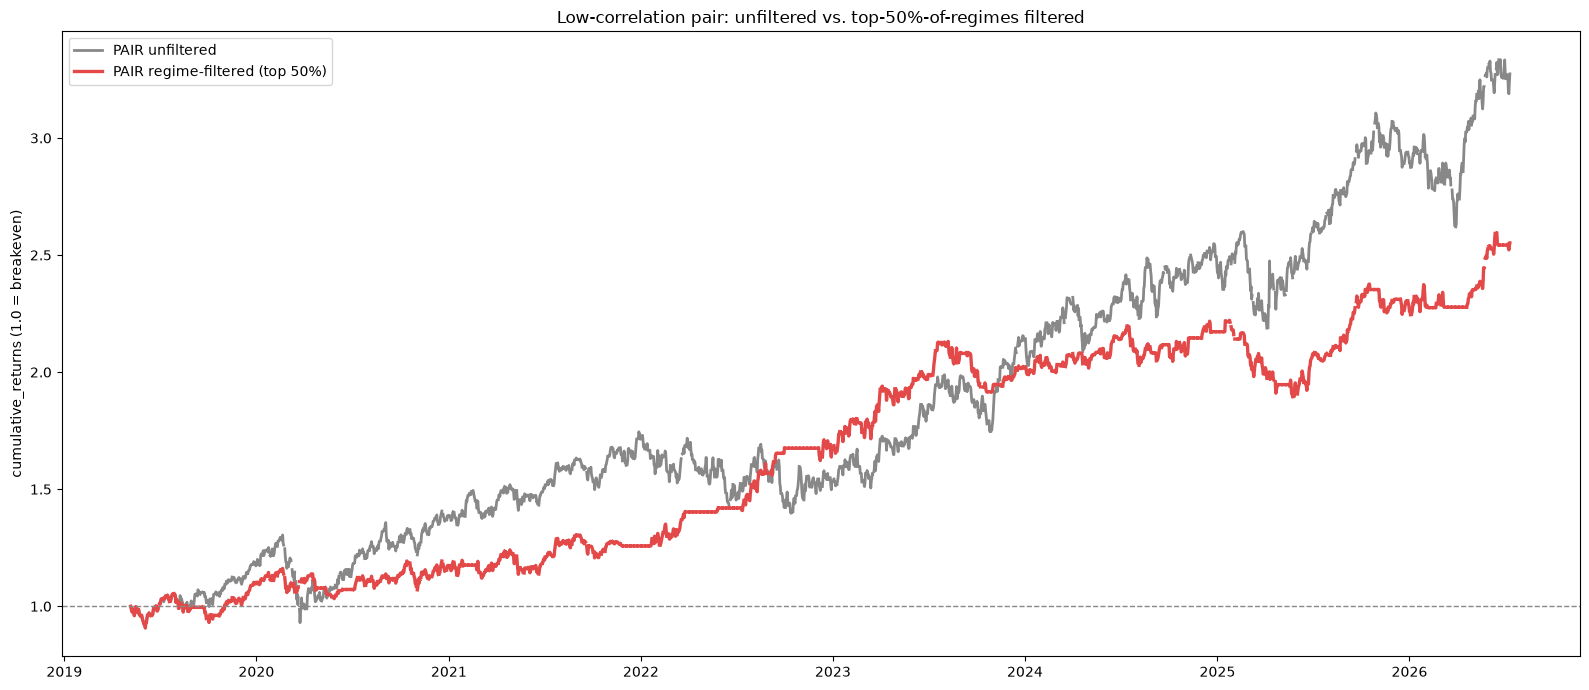

In [8]:
fig, ax = plt.subplots(figsize=(16, 7))
for name, color, lw in [("PAIR unfiltered", "#888888", 2.0), ("PAIR regime-filtered (top 50%)", "#e34948", 2.4)]:
    bt, _mw = backtests[name]
    if bt.reporter.merged is None:
        continue
    merged = bt.reporter.merged.set_index("time_close")
    ax.plot(merged.index, merged["algo__cumulative_returns"], label=name, color=color, linewidth=lw)

ax.axhline(1.0, color="#888888", linestyle="--", linewidth=1)
ax.set_ylabel("cumulative_returns (1.0 = breakeven)")
ax.set_title("Low-correlation pair: unfiltered vs. top-50%-of-regimes filtered")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


## Detailed report: the regime-filtered pair


Candles Processed: 84420
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,MNQ/USD,description
🏦 Gross Return %,254.4026,109.8391,106.8179,107.1813,133.3109,120.3894,107.6544,104.0529,112.5283,262.6263,387.7521,"Ending NAV as a percent of starting capital (100 + net_return_percent) -- not ""return before fees""."
💰 Net Return %,154.4026,9.8391,6.8179,7.1813,33.3109,20.3894,7.6544,4.0529,12.5283,162.6263,287.7521,Your actual gain over the backtest window.
📉 Max Drawdown %,-14.6576,-11.6437,-11.1077,-8.4259,-4.7229,-10.0996,-7.6079,-14.6576,-4.1912,-35.4168,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
⏱️ Max Drawdown Duration (days),313,136,231,123,27,146,149,230,105,719,751,How long it took to recover the loss. Shorter is better.
📊 Sharpe Ratio,0.8686,0.8141,0.4280,0.4724,1.9101,1.1537,0.6236,0.3227,1.7427,0.6392,0.7295,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
📊 Sortino Ratio,1.2548,1.1612,0.5751,0.6726,2.9639,1.7954,0.8627,0.4524,2.9248,0.9137,1.0539,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
🌪️ Annualized Volatility %,11.0210,13.1678,12.4119,11.5463,10.6945,11.6984,8.7585,10.0660,9.0811,16.6830,20.8049,How much the equity curve swings per year. Lower = smoother.
📈 CAGR %,13.8641,15.3413,6.8179,7.2017,33.4162,20.4508,7.6544,4.0643,25.1556,14.3689,20.7361,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
📐 Calmar Ratio,0.9459,1.3176,0.6138,0.8547,7.0753,2.0249,1.0061,0.2773,6.0020,0.4057,0.5852,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
🔁 Recovery Factor,10.5340,0.8450,0.6138,0.8523,7.0530,2.0188,1.0061,0.2765,2.9892,4.5918,8.1209,Total net profit ÷ max drawdown. >2 solid.


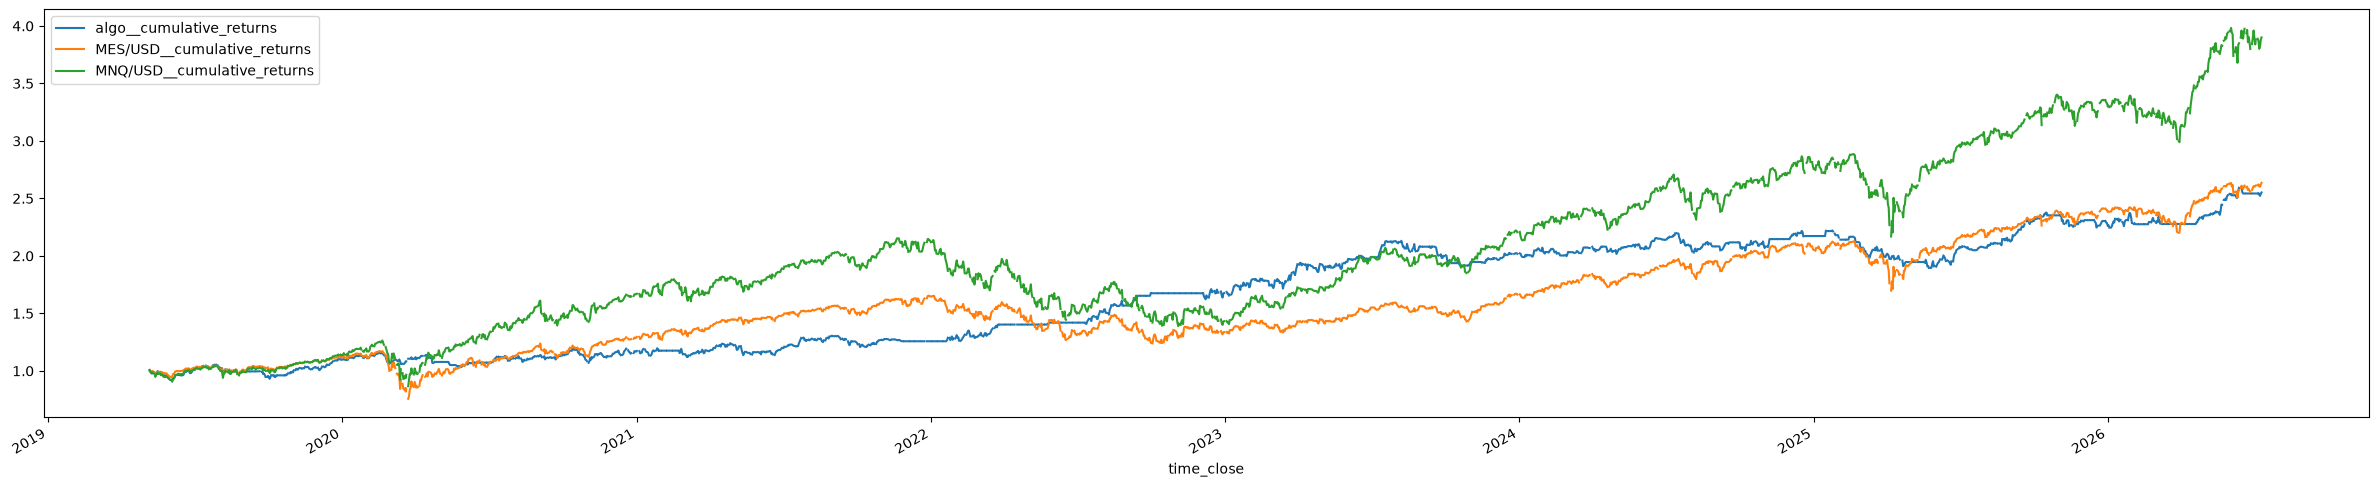

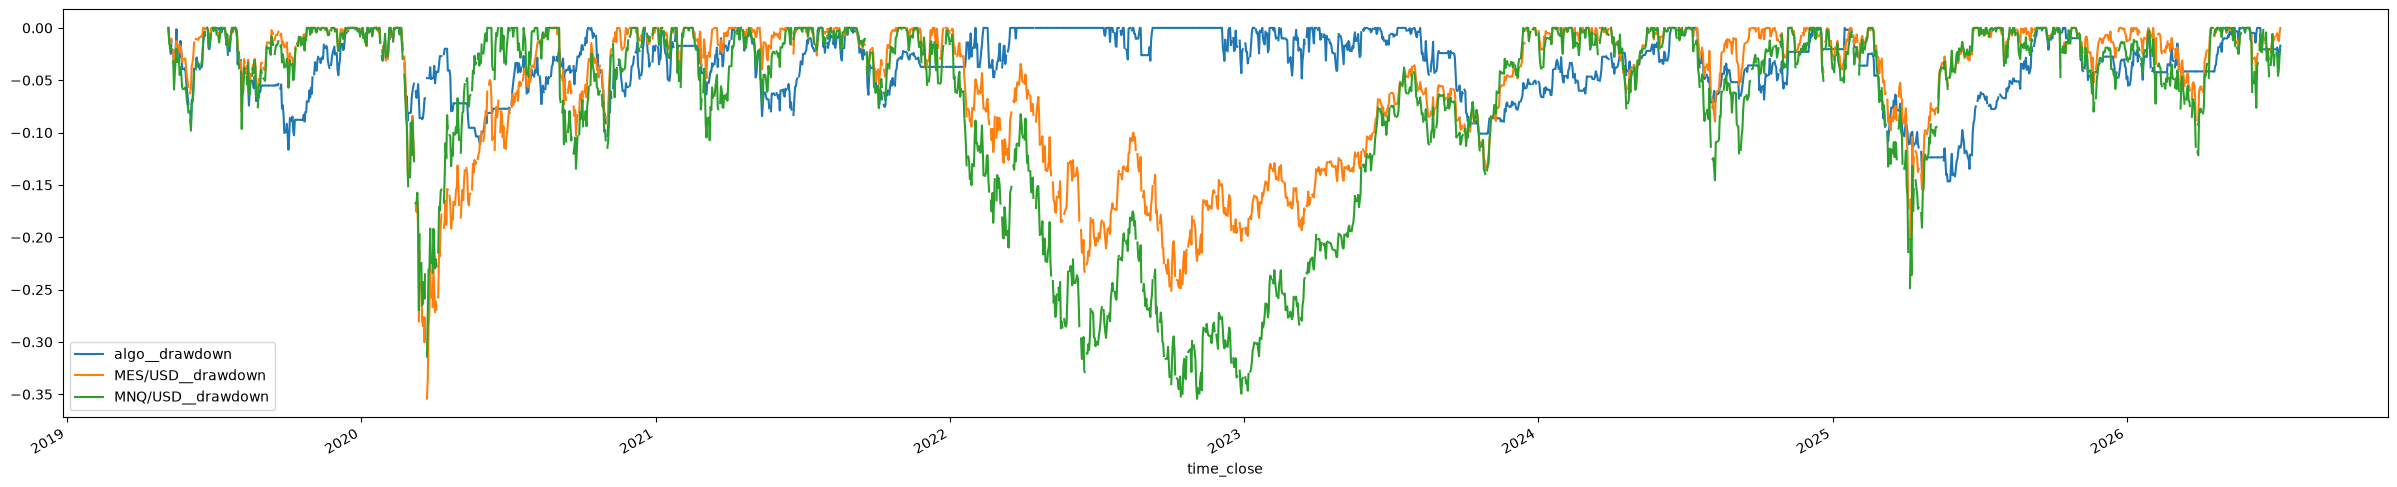

In [9]:
print("Candles Processed:", pair_filtered_bt.market.current["num"])
print("Account failed (drawdown breach):", pair_filtered_mw.account_failed)

display(HTML(pair_filtered_bt.reporter.summary_html_table(split="Y")))

if pair_filtered_bt.reporter.merged is not None:
    pair_filtered_bt.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        "MES/USD__cumulative_returns",
        "MNQ/USD__cumulative_returns",
    ], figsize=(30, 6))

    pair_filtered_bt.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        "MES/USD__drawdown",
        "MNQ/USD__drawdown",
    ], figsize=(30, 6))


## Findings

*(placeholder -- rewritten after execution with real numbers)*


## Findings

**Sizing check passes**: pair filtered trades (1,268) exactly equals the
sum of the two solo-filtered runs (601+667).

| run | net_return | sharpe | max_dd | dollar_profit_factor | trades |
|---|---|---|---|---|---|
| MES SuperTrend, unfiltered | +49.0% | 0.44 | -23.2% | 1.17 | 1109 |
| MES SuperTrend, top-50% filtered | +37.9% | **0.71** | **-6.2%** | 1.34 | 601 |
| MNQ Bollinger MR, unfiltered | +110.7% | 0.69 | -15.1% | 1.16 | 1099 |
| MNQ Bollinger MR, top-50% filtered | +74.7% | 0.69 | -11.0% | 1.22 | 667 |
| PAIR, unfiltered | +224.9% | 0.75 | -28.7% | 1.18 | 2208 |
| **PAIR, top-50% filtered** | **+154.4%** | **0.87** | **-14.7%** | **1.26** | 1268 |

**This is a genuine risk/return trade-off, not the free lunch
`combined_with_regime_filter.ipynb` found.** Sharpe improves (0.75 -> 0.87)
and drawdown roughly halves (-28.7% -> -14.7%), but net return drops by 70
points (+224.9% -> +154.4%) -- still a very strong number, just meaningfully
lower than unfiltered. MES SuperTrend's own drawdown improvement is the most
dramatic single number in this notebook (-23.2% -> -6.2%, a 73% relative
reduction) but comes with an 11-point return give-up.

**Why this filter behaves so differently from the earlier `profit_factor >
1` gate**: that gate only excluded regimes that were *actually losing
money* (profit_factor below 1.0) -- zero exclusions for these two specific
sleeves, since neither had any losing regime. **This "top 50%" rule always
excludes exactly half the regimes regardless of whether they're still
profitable** -- and here, every excluded regime for both sleeves was still
solidly profit_factor > 1 (MES SuperTrend's worst-ranked regimes were 1.14
and 1.07; MNQ Bollinger MR's were 1.41 and 1.47). The filter is discarding
real, demonstrated edge along with reducing risk, not just cutting bad
pockets -- a fundamentally blunter instrument than a profitability
threshold.

**When each approach is the right one**: if the objective is the single
best risk-adjusted *and* absolute result, `combined_with_regime_filter.
ipynb`'s threshold-based gate dominates (it improved every metric
simultaneously, no trade-off at all). If the objective is deliberately
trading return for a much smoother ride -- e.g. as a base for volatility-
targeted leverage, where a strategy with unchanged Sharpe but half the
drawdown can be levered up to roughly double its return at the *original*
risk level -- this top-50% filter is a legitimate, different lever, not a
worse version of the same idea.

**Same open caveat as before**: both rules were derived from a single
full-history split. Neither has been walk-forward validated yet -- that
remains the next step before treating either filter as more than a
promising, unconfirmed observation.